
# Práctica - 2 - Clasificación

Plantear una TAD para la siguiente problemática:

El gobierno de la Ciudad de México (CDMX) ha expresado su satisfacción con el trabajo y los resultados obtenidos en los últimos entregables por parte del equipo de Ciencia de Datos de la Generación 36, resolviendo los problemas de demanda de ecobicis.

Es por ello que ahora solicita la colaboración para los laboratorios de análisis clínicos de la CDMX, donde están a punto de lanzar una prueba de concepto para un producto que predice si un paciente, en alguna de sus revisiones, tiene riesgo de sufrir un derrame cerebral, basado en síntomas o padecimientos preexistentes. Se desea resolver esta problemática utilizando modelos de Machine Learning.

Objetivo:

Construir la TAD utilizando los datos del archivo "healthcare.csv", planteando el problema como una solución de clasificación binaria.

Requisitos:

**Subir el código en formato Jupyter Notebook con el siguiente nombre:
Formato: APELLIDOPATERNO_APELLIDOMATERNO_PRIMERNOMBRE_P02.ipynb
Ejemplo: GOMEZ_AUSSENAC_LUIS_P02.ipynb

**Subir la TAD en formato Parquet con el nombre en el mismo formato que el código:
Formato: APELLIDOPATERNO_APELLIDOMATERNO_PRIMERNOMBRE_P02.parquet
Ejemplo: GOMEZ_AUSSENAC_LUIS_P02.parquet

**El código debe incluir los siguientes elementos:
Carga de Datos
Limpieza de Datos
Ingeniería de Datos
Análisis exploratorio de Datos (para variables discretas y continuas)
Construcción de la TAD
**El código debe cumplir con los siguientes puntos:
Incluir al menos 3 nuevas variables o columnas dentro del apartado de ingeniería de variables.
Incluir la gráfica de tipo hist() de las variables finales de la TAD.
Imprimir la TAD al final del código.

### Librerias

In [7]:
import pandas as pd
import numpy as np
import os
import gc ##Limpia mi memoria RAM

##ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns


In [11]:
#### visualizacion de los datos
pd.set_option( 'display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

### Carga de datos

In [12]:
!ls -l


total 8956
-rw-r--r-- 1 alex alex  244125 Sep 20 19:12 GARIBAY_MORALES_ALEJANDRO_P1.ipynb
-rw-r--r-- 1 alex alex 7695897 Sep 13 22:47 GARIBAY_MORALES_ALEJANDRO_T2.ipynb
-rw-r--r-- 1 alex alex  783625 Sep 13 21:04 GARIBAY_MORALES_ALEJANDRO_T3.ipynb
-rw-r--r-- 1 alex alex   74664 Sep 20 22:27 GARIBAY_MORALES_ALEJANDRO_T4.ipynb
-rw-r--r-- 1 alex alex  359229 Sep 20 23:25 GARIBAY_MORALES_ALEJANDRO_T5.ipynb
-rw-r--r-- 1 alex alex    1452 Sep 27 18:02 P2.ipynb


In [15]:
%cd datos


/home/alex/DiplomadoCD/Modulo1/datos


In [16]:
df = pd.read_csv( "healthcare.csv" )

In [17]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1
5,56669,Male,81.0000,0,0,Yes,Private,Urban,186.2100,29.0000,formerly smoked,1
6,53882,Male,74.0000,1,1,Yes,Private,Rural,70.0900,27.4000,never smoked,1
7,10434,Female,69.0000,0,0,No,Private,Urban,94.3900,22.8000,never smoked,1
8,27419,Female,59.0000,0,0,Yes,Private,Rural,76.1500,NaN,Unknown,1
9,60491,Female,78.0000,0,0,Yes,Private,Urban,58.5700,24.2000,Unknown,1


In [18]:
df.shape

(5110, 12)

### Limpieza

In [19]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [23]:
for c in df.columns:
    print(c, df[c].map(type).unique().tolist() )

id [<class 'int'>]
gender [<class 'str'>]
age [<class 'float'>]
hypertension [<class 'int'>]
heart_disease [<class 'int'>]
ever_married [<class 'str'>]
work_type [<class 'str'>]
Residence_type [<class 'str'>]
avg_glucose_level [<class 'float'>]
bmi [<class 'float'>]
smoking_status [<class 'str'>]
stroke [<class 'int'>]


In [21]:
# veamos valores nulos
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [22]:
resumen_nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": df.isnull().mean() * 100
})
print(resumen_nulos)

                   nulos  porcentaje
id                     0      0.0000
gender                 0      0.0000
age                    0      0.0000
hypertension           0      0.0000
heart_disease          0      0.0000
ever_married           0      0.0000
work_type              0      0.0000
Residence_type         0      0.0000
avg_glucose_level      0      0.0000
bmi                  201      3.9335
smoking_status         0      0.0000
stroke                 0      0.0000


In [ ]:
# dado que tenemos valores nulos, pero menos al 5%, vamor a imputar esos valores con la media de cada columna, para no perder datos.
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [26]:
# veremos como quedaron despues de la imputacionresumen_nulos = pd.DataFrame({
resumen_nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": df.isnull().mean() * 100
})
print(resumen_nulos)

                   nulos  porcentaje
id                     0      0.0000
gender                 0      0.0000
age                    0      0.0000
hypertension           0      0.0000
heart_disease          0      0.0000
ever_married           0      0.0000
work_type              0      0.0000
Residence_type         0      0.0000
avg_glucose_level      0      0.0000
bmi                    0      0.0000
smoking_status         0      0.0000
stroke                 0      0.0000


In [27]:
#vamos a borrar la variable de ID, ya que no nos aporta informacion para el modelo
df = df.drop(columns=['id'])

In [28]:
print(f"{df['gender'].value_counts(True,dropna=False)*100}\n")
print(f"{df['age'].value_counts(True,dropna=False)*100}\n")
print(f"{df['hypertension'].value_counts(True,dropna=False)*100}\n")
print(f"{df['heart_disease'].value_counts(True,dropna=False)*100}\n")
print(f"{df['ever_married'].value_counts(True,dropna=False)*100}\n")
print(f"{df['Residence_type'].value_counts(True,dropna=False)*100}\n")
print(f"{df['avg_glucose_level'].value_counts(True,dropna=False)*100}\n")
print(f"{df['bmi'].value_counts(True,dropna=False)*100}\n")
print(f"{df['smoking_status'].value_counts(True,dropna=False)*100}\n")
print(f"{df['work_type'].value_counts(True,dropna=False)*100}\n")
print(f"{df['stroke'].value_counts(True,dropna=False)*100}\n")

gender
Female   58.5910
Male     41.3894
Other     0.0196
Name: proportion, dtype: float64

age
78.0000   1.9961
57.0000   1.8591
52.0000   1.7613
54.0000   1.7025
51.0000   1.6830
           ...  
1.4000    0.0587
0.4800    0.0587
0.1600    0.0587
0.4000    0.0391
0.0800    0.0391
Name: proportion, Length: 104, dtype: float64

hypertension
0   90.2544
1    9.7456
Name: proportion, dtype: float64

heart_disease
0   94.5988
1    5.4012
Name: proportion, dtype: float64

ever_married
Yes   65.6164
No    34.3836
Name: proportion, dtype: float64

Residence_type
Urban   50.8023
Rural   49.1977
Name: proportion, dtype: float64

avg_glucose_level
93.8800    0.1174
73.0000    0.0978
72.4900    0.0978
91.6800    0.0978
91.8500    0.0978
            ...  
83.9400    0.0196
125.2000   0.0196
82.9900    0.0196
166.2900   0.0196
85.2800    0.0196
Name: proportion, Length: 3979, dtype: float64

bmi
28.1000   4.5010
28.7000   0.8023
28.4000   0.7436
27.7000   0.7241
26.7000   0.7241
           ...  
4

In [29]:
df['stroke'].value_counts(True)*100

stroke
0   95.1272
1    4.8728
Name: proportion, dtype: float64

Muy pocos casos de los strokes 

In [ ]:
df[df['amt'] < 500]['amt'].hist()

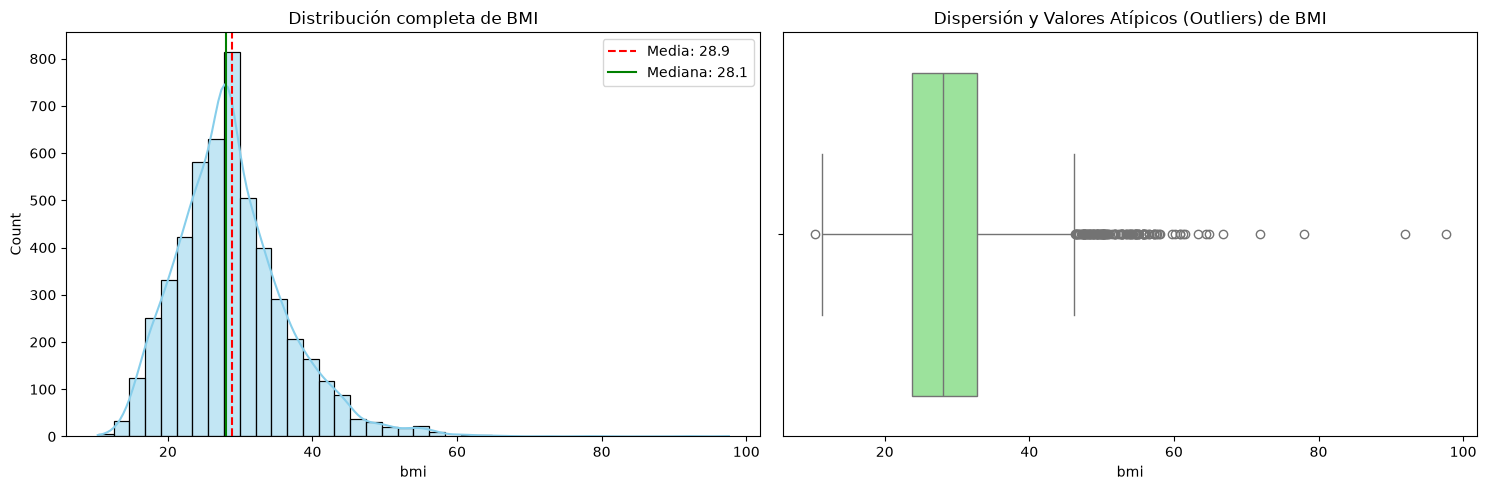

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el lienzo para dos gráficas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma con la Media y Mediana marcadas
sns.histplot(df['bmi'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f"Media: {df['bmi'].mean():.1f}")
axes[0].axvline(df['bmi'].median(), color='green', linestyle='-', label=f"Mediana: {df['bmi'].median():.1f}")
axes[0].set_title('Distribución completa de BMI')
axes[0].legend()

# 2. Boxplot para visualizar la dispersión y los Outliers
sns.boxplot(x=df['bmi'], ax=axes[1], color='lightgreen')
axes[1].set_title('Dispersión y Valores Atípicos (Outliers) de BMI')

plt.tight_layout()
plt.show()

In [32]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,28.1000,never smoked,1
2,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1
5,Male,81.0000,0,0,Yes,Private,Urban,186.2100,29.0000,formerly smoked,1
6,Male,74.0000,1,1,Yes,Private,Rural,70.0900,27.4000,never smoked,1
7,Female,69.0000,0,0,No,Private,Urban,94.3900,22.8000,never smoked,1
8,Female,59.0000,0,0,Yes,Private,Rural,76.1500,28.1000,Unknown,1
9,Female,78.0000,0,0,Yes,Private,Urban,58.5700,24.2000,Unknown,1



--- Distribución de Variables Continuas ---


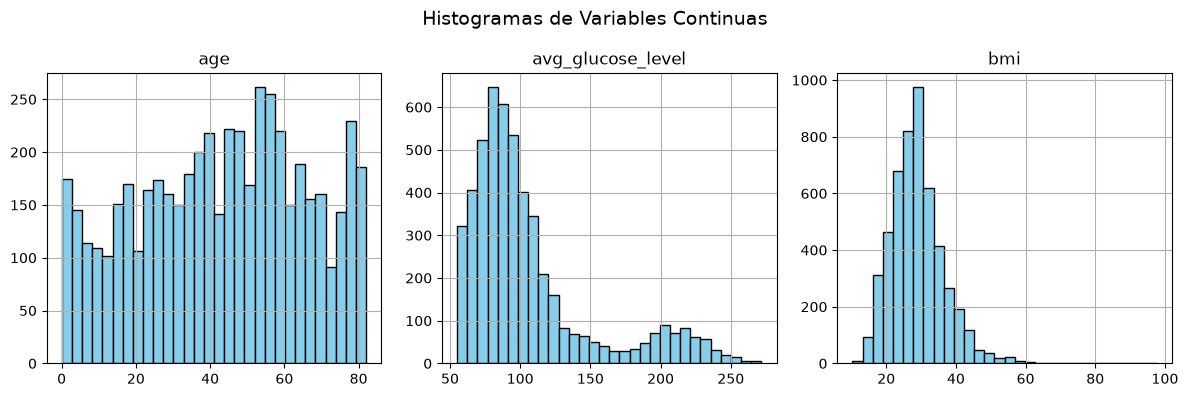

In [33]:
# --- EDA de Variables Continuas ---
vars_continuas = ['age', 'avg_glucose_level', 'bmi']
print("\n--- Distribución de Variables Continuas ---")
df[vars_continuas].hist(figsize=(12, 4), layout=(1, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Histogramas de Variables Continuas', fontsize=14)
plt.tight_layout()
plt.show()

Varialbes discretas


--- Distribución de Variables Discretas ---


/tmp/ipykernel_2791/3911104917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
/tmp/ipykernel_2791/3911104917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
/tmp/ipykernel_2791/3911104917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
/tmp/ipykernel_2791/3911104917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

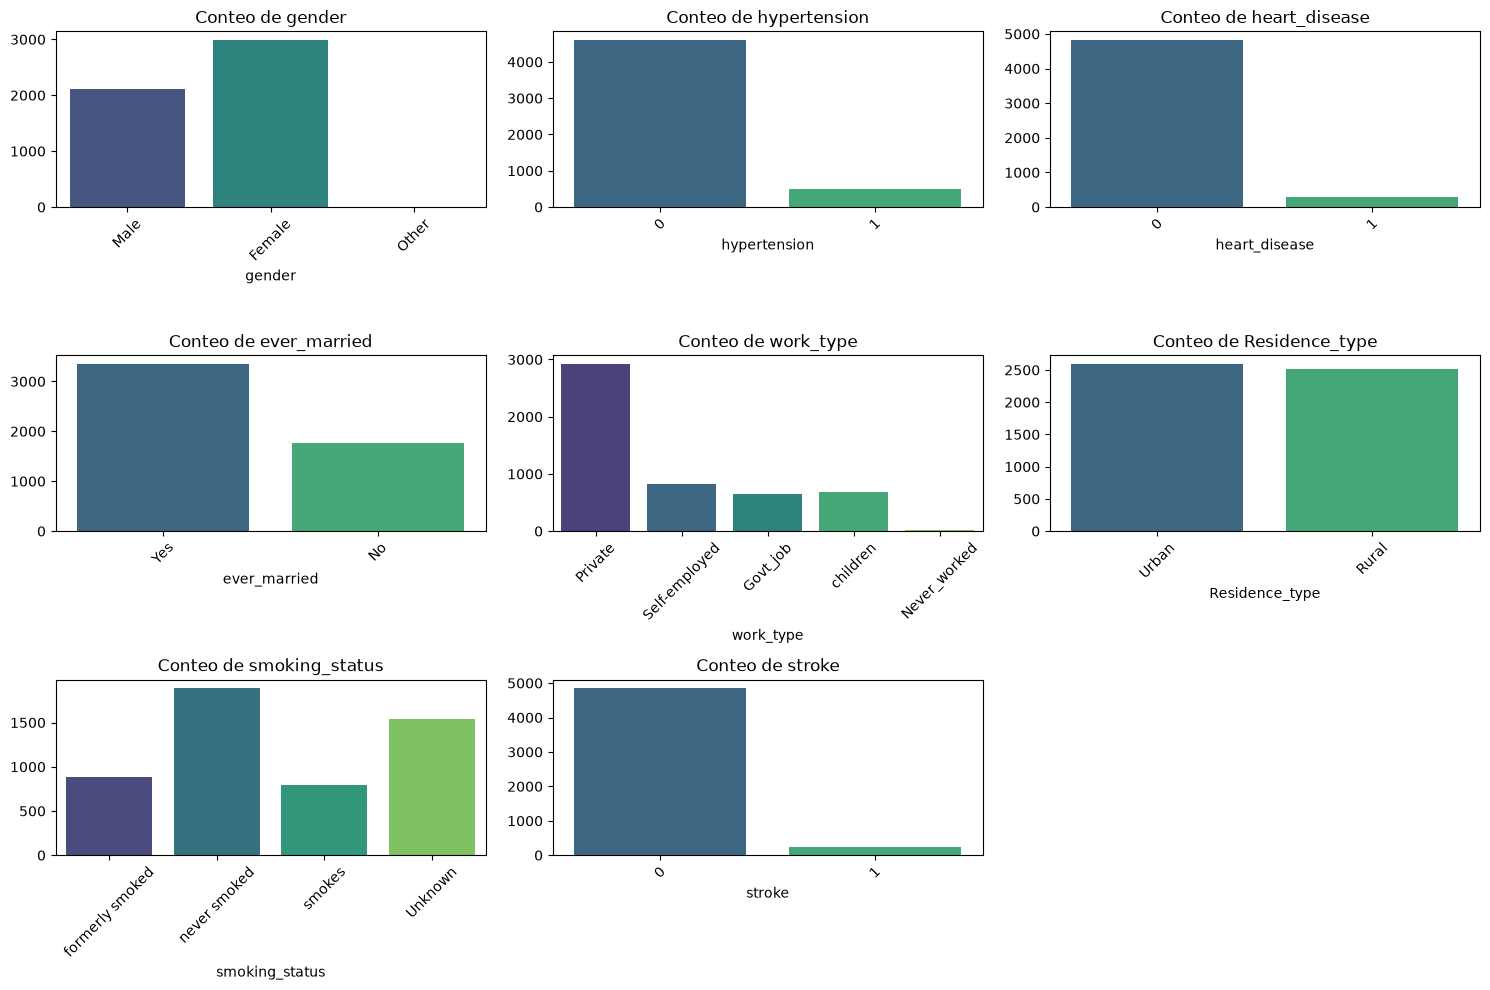

In [35]:
# Exploracion varialbes discretas
vars_discretas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                  'work_type', 'Residence_type', 'smoking_status', 'stroke']

print("\n--- Distribución de Variables Discretas ---")
plt.figure(figsize=(15, 10))
for i, var in enumerate(vars_discretas, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=var, palette='viridis')
    plt.title(f'Conteo de {var}')
    plt.xticks(rotation=45)
    plt.ylabel('')
plt.tight_layout()
plt.show()

## Ingenieria de VAriables

* edad
* riesgo de enfermedad (hipertension + corazon)
* peso
* riesgo diabetes
* glucosa alta entre el peso
* fumador o no fumador
* alto riesgo (hipertension, glucosa alta, sobrepeso, fumador)

In [36]:
## catalogemos edad
df['edad_categoria'] = pd.cut(
    df['age'], 
    bins=[0, 30, 60, 120], 
    labels=['Joven', 'Adulto', 'Adulto_Mayor']
)

In [37]:
# Categorías de Peso (Basado en el BMI)
df['peso_categoria'] = pd.cut(
    df['bmi'], 
    bins=[0, 18.5, 24.9, 29.9, 100], 
    labels=['Bajo_Peso', 'Normal', 'Sobrepeso', 'Obesidad']
)

In [38]:
# Riesgo de Diabetes (Basado en niveles de glucosa)
df['riesgo_diabetes'] = pd.cut(
    df['avg_glucose_level'], 
    bins=[0, 140, 199, 500], 
    labels=['Normal', 'Prediabetes', 'Diabetes']
)

In [39]:
#  Glucosa entre el peso (Proporción Glucosa / BMI)
df['glucosa_peso_ratio'] = df['avg_glucose_level'] / df['bmi']

In [40]:
# Fumador o No Fumador (1 = Fuma o Fumó, 0 = Nunca fumó o Desconocido)
df['es_fumador'] = df['smoking_status'].isin(['formerly smoked', 'smokes']).astype(int)

In [41]:
# persona alto riesgo (Combina: Hipertension + Glucosa Alta + Sobrepeso/Obesidad + Fumador)
# Glucosa alta >= 140, Sobrepeso/Obesidad (BMI >= 25)
df['alto_riesgo'] = (
    (df['hypertension'] == 1) & 
    (df['avg_glucose_level'] >= 140) & 
    (df['bmi'] >= 25.0) & 
    (df['es_fumador'] == 1)
).astype(int)

In [42]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,edad_categoria,peso_categoria,riesgo_diabetes,glucosa_peso_ratio,es_fumador,alto_riesgo
0,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1,Adulto_Mayor,Obesidad,Diabetes,6.2484,1,0
1,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,28.1000,never smoked,1,Adulto_Mayor,Sobrepeso,Diabetes,7.1961,0,0
2,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1,Adulto_Mayor,Obesidad,Normal,3.2591,0,0
3,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1,Adulto,Obesidad,Prediabetes,4.9776,1,0
4,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1,Adulto_Mayor,Normal,Prediabetes,7.2550,0,0
5,Male,81.0000,0,0,Yes,Private,Urban,186.2100,29.0000,formerly smoked,1,Adulto_Mayor,Sobrepeso,Prediabetes,6.4210,1,0
6,Male,74.0000,1,1,Yes,Private,Rural,70.0900,27.4000,never smoked,1,Adulto_Mayor,Sobrepeso,Normal,2.5580,0,0
7,Female,69.0000,0,0,No,Private,Urban,94.3900,22.8000,never smoked,1,Adulto_Mayor,Normal,Normal,4.1399,0,0
8,Female,59.0000,0,0,Yes,Private,Rural,76.1500,28.1000,Unknown,1,Adulto,Sobrepeso,Normal,2.7100,0,0
9,Female,78.0000,0,0,Yes,Private,Urban,58.5700,24.2000,Unknown,1,Adulto_Mayor,Normal,Normal,2.4202,0,0


# tipo de variables

In [43]:
df.shape

(5110, 17)